<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: poplolitas SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javiera Arévalo Díaz
- Nombre de alumno 2: Laura Maldonado Lagos


### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/lauraflm/MDS7202-Laboratorio-de-Programacion-Cientifica-para-Ciencia-de-Datos)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [2]:
!pip install xgboost

In [4]:
# Inserte su código aquí

In [3]:
#Lo primero es hacer el análisis de la base de datos
print(df.info())
num_cols = df.select_dtypes(include="number").columns.tolist()
print(df[num_cols].describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke             

In [4]:
nas_colum=df.isna().sum()
print(nas_colum)

Age                     0
Sex                     0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Stroke                  0
HighBP                  0
Diabetes                0
dtype: int64


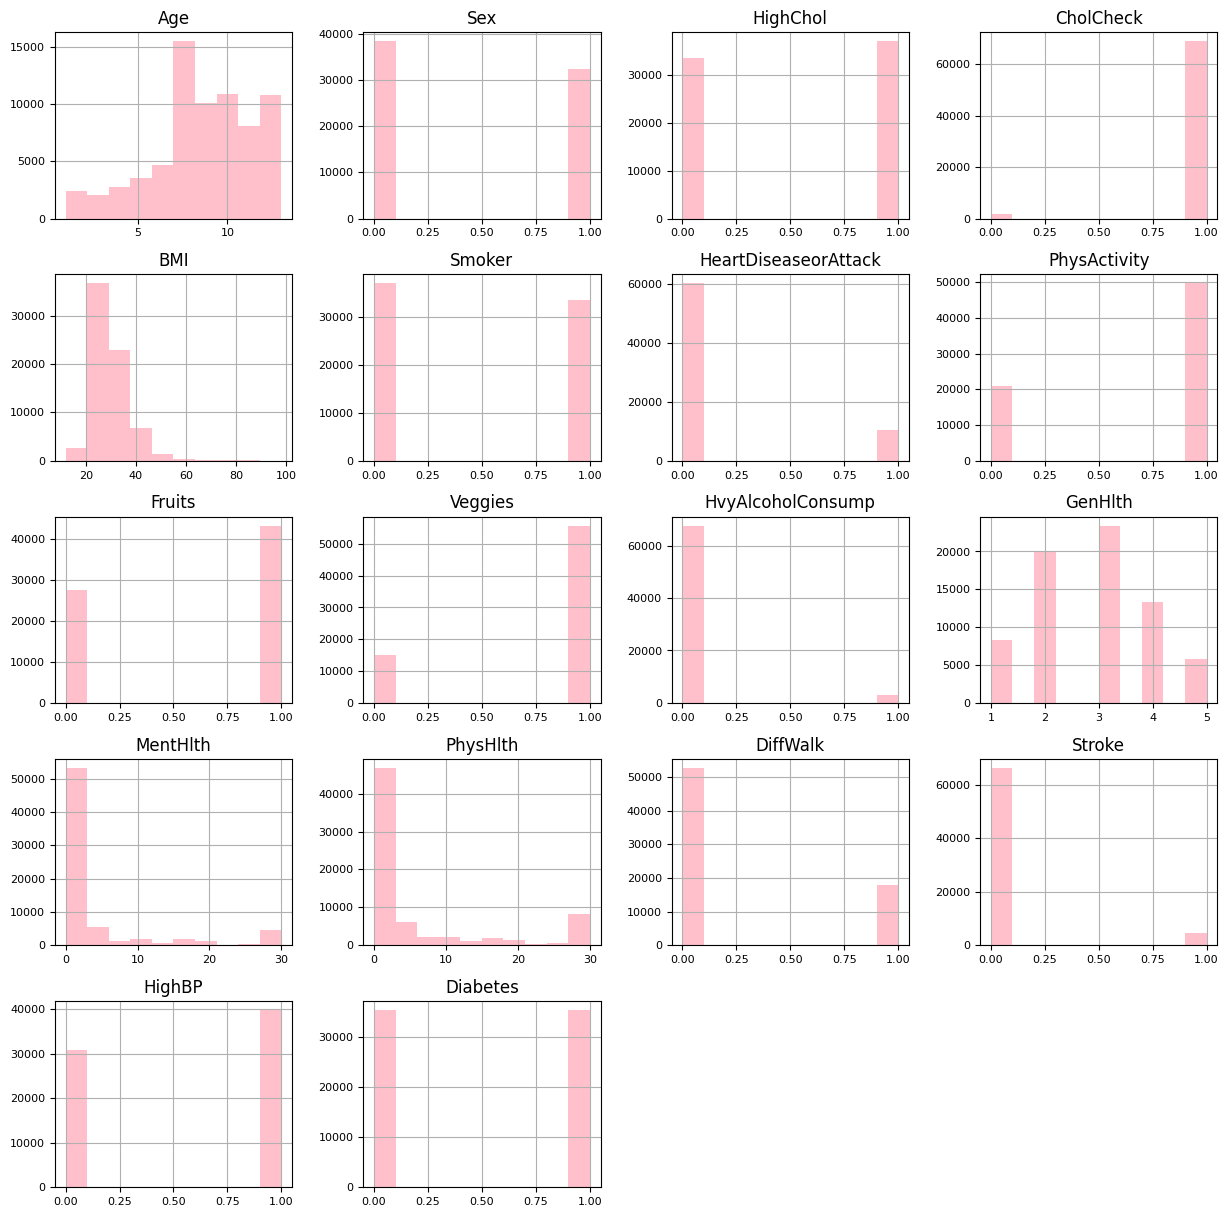

In [5]:
histrograma=df.hist(figsize=(15,15), color='pink', xlabelsize=8, ylabelsize=8)

Se puede visualizar que hay muchas variables que son binarias, es decir, toman valores 0 o 1. Hay dos variables que son ordinales que serían Age y GenHlth y, hay tres variables continuas que son BMI, MentHlth y PhysHlth.

Llama la atención que la variable de Age tiene como máximo una edad de 13 años, por lo cual este estudio estaría siendo centrado en niños y adolescentes. Esto es importante a considerar, ya que puede tratarse de datos faltantes o de un caso en donde se quiera estudiar las predicción de diabetes. Sin embargo, sería útil confirmar que los datos corresponden a casos reales, dado que es preocupante la edad máxima al realizar la comparación con la cantidad de personas que son fumadoras.

In [5]:
# Variables binarias
binary_cols = ['Sex','HighChol','CholCheck','Smoker','HeartDiseaseorAttack','PhysActivity','Fruits','Veggies','HvyAlcoholConsump','DiffWalk','Stroke','HighBP']

# Continuas
cont_cols = ['BMI','MentHlth','PhysHlth']

# Ordinales
ordinal_cols = ['Age','GenHlth']

Lo que se hace es definir el orden de las variables ordinales, para definir como se ordenan de forma natural estas características.

Se aplica RobustScaler a las variables continuas, esto ya que es sensible a outliers, por lo que es ideal cuando hay valores extremos como lo es en este caso.

Entonces, se separada por tipo de variable y se aplica lo necesario para cada grupo. Para las continuas, se hace un escalado robusto, para las ordinales se hace OrdinalEncoder y para las binarias, se dejan tal cual (0/1), no necesitan escalado.

Por otro lado, se genera el conjunto de entrenamiento y el de prueba, con una proporción de 1/3 en el conjunto de prueba.

In [6]:
from sklearn.model_selection import train_test_split

target = 'Diabetes'

y = df[target].astype(int)
X = df.drop(columns=[target])


X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer, RobustScaler, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ordinal_categories = [
    list(range(1,14)),  # Age: 1..13
    [1,2,3,4,5]         # GenHlth: 1=mejor ... 5=peor
]

preproc_cont = Pipeline([('robust', RobustScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ('cont', preproc_cont, cont_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ('bin', 'passthrough', binary_cols),],
    remainder='drop', verbose_feature_names_out=False).set_output(transform='pandas')

In [8]:
target = 'Diabetes'

# Conteo de las clases
counts = df[target].value_counts(dropna=False).sort_index()

print("Conteo por clase")
print(counts.to_string())

Conteo por clase
Diabetes
0.0    35346
1.0    35346


Se destaca que las clases se encuentran perfectamente balanceadas, esto es muy positivo, ya que beneficia la capacidad de generabilidad del modelo.

In [9]:
from sklearn.metrics import classification_report
from xgboost import XGBClassifier


xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=42, n_jobs=-1)

pipe = Pipeline([('prep', preprocessor), ('xgb', xgb)])
pipe.fit(X_tr, y_tr)

y_pred = pipe.predict(X_te)
print(classification_report(y_te, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.774     0.703     0.737     11782
           1      0.728     0.795     0.760     11782

    accuracy                          0.749     23564
   macro avg      0.751     0.749     0.749     23564
weighted avg      0.751     0.749     0.749     23564



1. Se tiene que el modelo obtiene un accuracy total de 0.749, es decir, el modelo acierta en aproximadamente un 75% de las veces en el conjunto de prueba.
En cuanto a cada una de las clases, se tiene:

Clase 1 se tiene una precisión de 0.728, es decir que de los pacientes que el modelo predijo con diabetes, el 72.8% realmente tienen diabetes. Por otro lado, el recall da un valor de 0.795, lo que indica que el modelo detecta correctamente el 79.5% de los pacientes con diabetes. Finalmente, en el F1-score se tiene un valor de 0.760, por lo que se tiene un balance entre precision y recall, útil dado que hay trade-off.

Para la clase 0, se tiene una precisión de 0.774, es decir que de los pacientes que el modelo predijo sin diabetes, el 77.4% realmente no tienen diabetes. Para el recall toma un valor de 0.703, entonces el modelo detecta correctamente el 70.3% de los pacientes sin diabetes. Finalmente, para el f1 tiene un valor de 0.737, lo que de igual forma indica que hay un balance entre precisión y recall.

2. Estas métricas muestran cómo funciona el modelo de manera general y por clase. La precision indica qué tan confiables son las predicciones de diabetes, el recall muestra qué tan bien se detectan los casos reales, y el F1-score combina ambos para dar un balance. El support indica cuántas muestras hay por clase, y la accuracy refleja el porcentaje total de aciertos. Los promedios macro y weighted resumen el desempeño global considerando todas las clases de forma simple o ponderada.

3. A través de las métricas (precision, recall, f1, accuracy) se evalua el desempeño global, pero no dicen si el modelo está usando las features correctas de manera lógica o interpretativa.

Para evaluar si las features son relevantes se necesitan otros métodos, como por ejemplo ver la importancia de las características. También se puede ver la permutation importance para ver impacto en métricas.Finalmente, se puede incluir el SHAP values para interpretación local y global.

Entonces,e stas métricas nos indica que hay un buen desempeño de manera global, pero no garantiza que las features elegidas sean las “correctas” o las más interpretables.
Necesitas análisis adicional para interpretabilidad y confiabilidad de las variables.

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

In [ ]:
# Inserte su código aquí

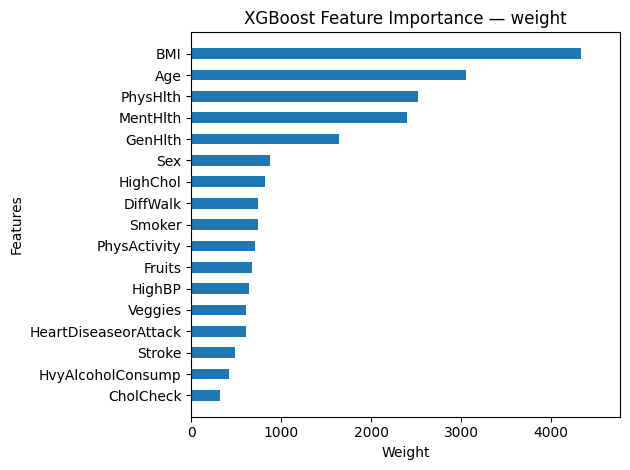

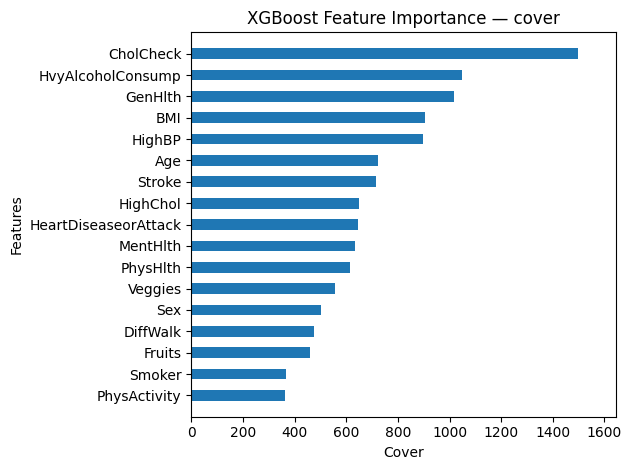

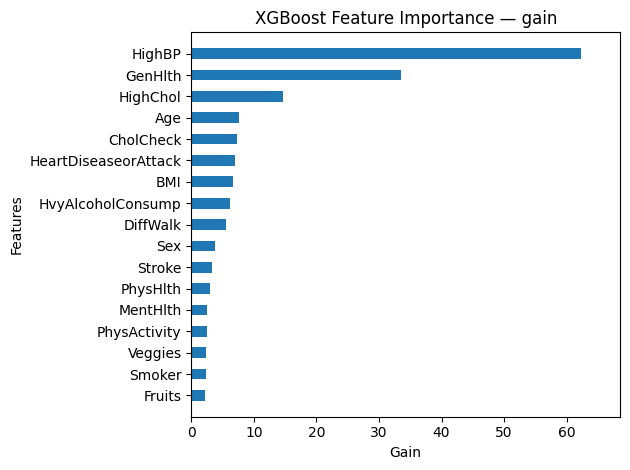

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

def plot_xgb_importances(pipe, X_tr, step_model_name="xgb", step_prep_name="prep"):
    """
    pipe: Pipeline ya entrenado (con steps 'prep' y 'xgb' por defecto)
    X_train: DataFrame original antes del preprocesamiento (usado sólo para obtener nombres)
    step_model_name: nombre del paso del modelo en el Pipeline
    step_prep_name: nombre del paso de preprocesamiento en el Pipeline
    """
    # 1) Booster desde el pipeline
    booster = pipe.named_steps[step_model_name].get_booster()

    # Obtener nombres de features transformadas
    prep = pipe.named_steps[step_prep_name]
    try:
        Xt_cols = prep.transform(X_tr.iloc[[0]]).columns.tolist()
    except Exception:
        Xt_cols = prep.get_feature_names_out().tolist()

    # 3) Asignar nombres al booster
    booster.feature_names = Xt_cols

    for imp_type in ["weight", "cover", "gain"]:
        ax = xgb.plot_importance(
            booster,
            importance_type=imp_type,
            show_values=False,
            height=0.5,
            grid=False)

        ax.set_title(f"XGBoost Feature Importance — {imp_type}")
        ax.set_xlabel(imp_type.capitalize())
        ax.set_ylabel("Features")
        plt.tight_layout()
        plt.show()

plot_xgb_importances(pipe, X_tr, step_model_name="xgb", step_prep_name="prep")

2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)

Podemos ver que los resultados van variando a medida que se van cambiando los gráficos (weight, cover y gain). Esto se debe a que cada métrica mide una cosa distinta y por eso el orden de importancia de las variables cambia.
En primer lugar, weight mide cuántas veces aparece un atributo en algún split. Este favorece a las variables que se usan en muchos nodos (aunque aporten poco en cada uno). En segundo lugar, cover mide cuántas muestras toca el split promedio. Favorece variables que se usan cerca de la raíz. Finalmente, el gain mejora media de la pérdida al usar esa variable. Destaca variables que, aunque se usen poco, dan grandes mejoras en los nodos donde aparecen.

En los gráficos se ve reflejado este cambio entre los tipos, por ejemplo, BMI/Age dominan en weight, CholCheck/HvyAlcoholConsump en cover, y HighBP/GenHlth en gain.

3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

Las importancias no alcanzan para interpretar bien un modelo de árboles. Estas son medidas globales, es decir, no dicen si el efecto es positivo o negativo, cómo es la relación, qué interacciones existen, ni cómo cambia caso por caso.
Entonces, esto no nos indica si un valor alto de una variable (como podría ser BMI en wieght) aumenta o disminuye la probabilidad de padecer diabetes.

Las desventajas que tienen es que poseen sesgo hacia variables con muchos valores, inestabilidad si cambian los datos/semilla, y diluyen la importancia cuando hay variables correlacionadas. Para entender mejor, conviene complementar con permutation importance, SHAP, y curvas de dependencia parcial/ICE o ALE.

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [ ]:
# Inserte su código aquí

/tmp/ipython-input-3833076678.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(stacked[perm_sorted_idx].T, vert=False, labels=feature_names[perm_sorted_idx])


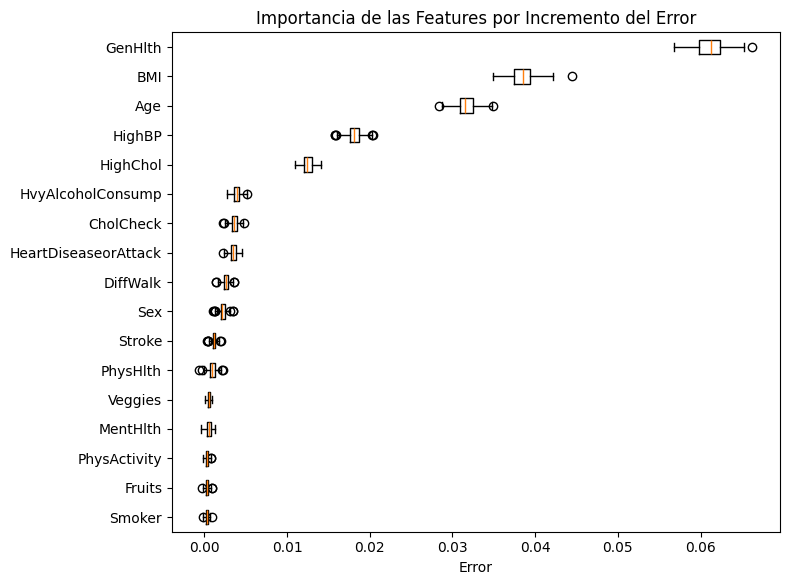

,feature,mean_drop,std_drop
0,GenHlth,0.061150,0.001663
1,BMI,0.038497,0.001405
2,Age,0.031604,0.001180
3,HighBP,0.018121,0.000843
4,HighChol,0.012512,0.000675
5,HvyAlcoholConsump,0.003884,0.000449
6,CholCheck,0.003609,0.000428
7,HeartDiseaseorAttack,0.003498,0.000428
8,DiffWalk,0.002541,0.000376
9,Sex,0.002205,0.000373


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score

N_RUNS = 30
N_REPEATS = 10
METRIC = "roc_auc"
TEST_SUBSAMPLE = None

# Eval set transformado
if TEST_SUBSAMPLE is not None and TEST_SUBSAMPLE < len(X_te):
    X_eval = X_te.sample(TEST_SUBSAMPLE, random_state=42)
    y_eval = y_te.loc[X_eval.index]
else:
    X_eval, y_eval = X_te, y_te

Xt_eval = pipe.named_steps["prep"].transform(X_eval)
xgb_model = pipe.named_steps["xgb"]

booster = xgb_model.get_booster()
booster.feature_names = list(Xt_eval.columns)
feature_names = np.array(booster.feature_names)

# Métrica
use_proba = METRIC == "roc_auc"
def scorer_fn(est, X, y):
    if use_proba:
        p = est.predict_proba(X)[:, 1]
        return roc_auc_score(y, p)
    else:
        yhat = est.predict(X)
        return f1_score(y, yhat)

# 30
results = []
for seed in range(N_RUNS):
    res = permutation_importance(
        estimator=xgb_model,
        X=Xt_eval,
        y=y_eval,
        n_repeats=N_REPEATS,
        random_state=seed,
        scoring=scorer_fn
    )
    results.append(res)

# Cada res.importances tiene shape (n_features, n_repeats)
stacked = np.hstack([r.importances for r in results])  # -> (n_features, N_RUNS*N_REPEATS)

# Orden por media de caída de métrica
means = stacked.mean(axis=1)
perm_sorted_idx = means.argsort()  # ascendente

# Boxplot horizontal
plt.figure(figsize=(8, 0.35*len(feature_names)))
plt.boxplot(stacked[perm_sorted_idx].T, vert=False, labels=feature_names[perm_sorted_idx])
plt.title("Importancia de las Features por Incremento del Error")
plt.xlabel("Error")
plt.tight_layout()
plt.show()

# Top-10 con media y std entre TODAS las permutaciones
order_desc = means.argsort()[::-1]
top = 10
tabla_top = pd.DataFrame({
    "feature": feature_names[order_desc][:top],
    "mean_drop": means[order_desc][:top],
    "std_drop": stacked.std(axis=1, ddof=1)[order_desc][:top],
})
display(tabla_top)


Accuracy base: 0.7493 | Repeticiones: 30


,feature,mean_drop,std_drop
0,GenHlth,0.054375,0.002371
1,BMI,0.029991,0.002002
2,Age,0.026774,0.001614
3,HighBP,0.016347,0.001059
4,HighChol,0.010069,0.001152
5,HvyAlcoholConsump,0.003648,0.000572
6,CholCheck,0.003508,0.000503
7,DiffWalk,0.002532,0.000695
8,HeartDiseaseorAttack,0.002508,0.000782
9,Sex,0.002405,0.000617


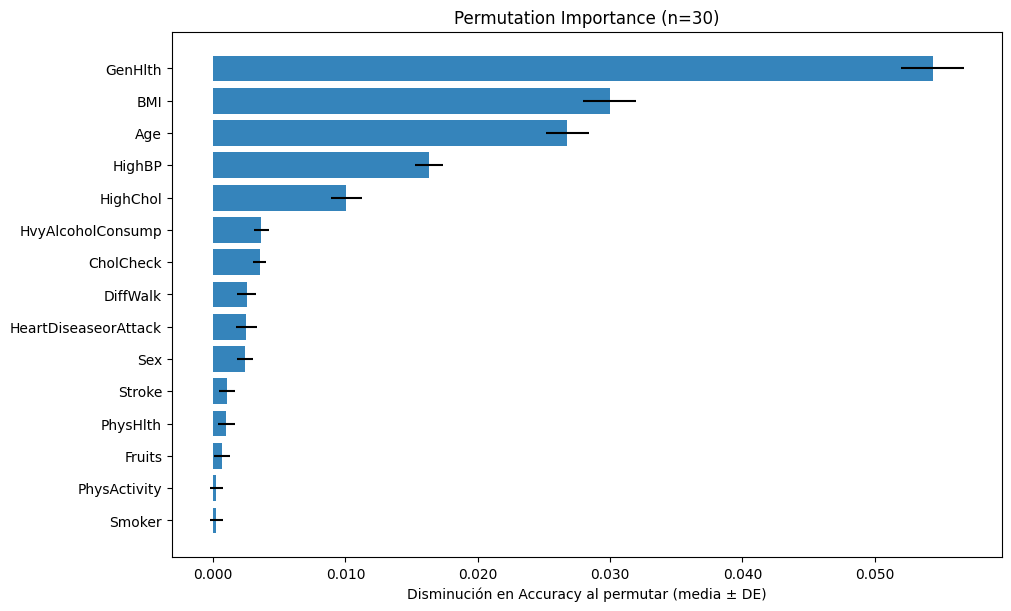

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import accuracy_score

# Aseguramos que los resultados sean reproducibles
np.random.seed(19)

# Obtener el preprocesador y clasificador del pipeline
_prep  = pipe.named_steps['prep']
_clf   = pipe.named_steps['xgb']  # Cambié 'clf' a 'xgb' porque es el nombre en tu pipeline
_boost = _clf.get_booster()

# Obtener las características (features) del modelo, con el orden correcto
_feats = [str(f) for f in (_boost.feature_names or _prep.get_feature_names_out())]

# Transformar el conjunto de prueba (X_test) con el preprocesamiento del pipeline
_Xt = _prep.transform(X_te)[_feats].copy()

# Calcular la precisión base (accuracy) del modelo
_base_acc = accuracy_score(y_te, _clf.predict(_Xt))

# Definir cuántas repeticiones queremos hacer en la permutación
N = 30

# Diccionario para almacenar los drops de cada feature
drops = {f: [] for f in _feats}

# Realizar la permutación N veces
for _ in range(N):
    for f in _feats:
        Xp = _Xt.copy()
        # Permutar los valores de la feature f
        Xp.loc[:, f] = np.random.permutation(Xp[f].values)
        # Calcular la caída en accuracy comparado con el modelo original
        drops[f].append(_base_acc - accuracy_score(y_te, _clf.predict(Xp)))

# Crear un DataFrame con las importancias de las features
imp_df = pd.DataFrame({
    "feature": _feats,
    "mean_drop": [np.mean(drops[f]) for f in _feats],
    "std_drop":  [np.std(drops[f], ddof=1) for f in _feats],
}).sort_values("mean_drop", ascending=False).reset_index(drop=True)

# Mostrar la precisión base y el número de repeticiones
print(f"Accuracy base: {_base_acc:.4f} | Repeticiones: {N}")
display(imp_df.head(15))

# Gráfico de la importancia de las features
plot_df = imp_df.head(15).iloc[::-1]  # Invertir para mostrar la más importante arriba
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# Crear el gráfico de barras horizontales con las importancias y desviación estándar
ax.barh(plot_df["feature"], plot_df["mean_drop"], xerr=plot_df["std_drop"], alpha=0.9)
ax.set_xlabel("Disminución en Accuracy al permutar (media ± DE)")
ax.set_title(f"Permutation Importance (n={N})")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # Formato para los valores en el eje X

# Mostrar el gráfico
plt.show()


1. Código
2. La desviación estándar señala (std_drop) que tan estable/confiable es la importancia estimada de cada variable a lo largo de las 30 repeticiones. Por lo tanto, refleja la variabilidad de la caida de "roc-auc" a lo largo de cada corrida. Por lo tanto, si la std_drop es baja se podemos decir que la variable es consistente, no así si es alta, ya que eso indica que cambia mucho entre repeticiones (posible colinealidad). Como las desviaciones estándar son pequeñas, podemos decir que las variables (mayor 0.001) son consistentes (al menos el top 10).
3. Visualización
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)

  El método de permutación mide la importancia de cada variable observando cuánto disminuye la métrica de desempeño del modelo (en este caso, el roc-auc) cuando se rompen aleatoriamente los valores de esa feature.

  En otras palabras, si al permutar una variable el modelo pierde precisión de forma significativa, esa variable es considerada más relevante para las predicciones.


  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)

  Las cinco primeras son GenHlth, BMI, Age, HighBP y HighChol. Todas tienen bastante sentido, dado que por conocimientos previos sabemos que son variables directamente relacionadas a la diabetes. Tal como el BMI que nos indica la medida de la grasa corporal (basada en altura y peso), presión alta e índices de colesterol altos, todos factores conocidos que aumentan el riesgo de tener la enfermedad comentada. La variable que requiere mayor estudio a nuestra opinión es la de Age, más aun al ser la tercera más relevante, pero existe una muestra de edades restringida como se mencionó en la sección de EDA.

  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)

  Cambian dado que existe una mejor interpretabilidad de las features importances al contar con la desviación estándar, el promedio y la priorización del "roc-auc", por lo que es mucho más robusto. Cabe mencionar, que las variables destacadas fueron igualmente seleccionadas por los otros métodos, tales como BMI, Age, highBP, entre otros. Pero todos destacados por alguno de los 3 métodos. Es posible mencionar que "gain" es el que comparte mayor similitud con el método agnóstico, pero dando más importancia a HighBP y seguidamente a GenHlth.

  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

  Ventajas:

  Es agnóstico al modelo: se puede aplicar a cualquier clasificador o pipeline.
  Mide la importancia en términos de la métrica real de evaluación, no de parámetros internos, en nuestro caso optamos por la métrica auc.
  Es fácil de interpretar, ya que muestra directamente la pérdida de rendimiento al alterar una variable.

  Desventajas:
  Es computacionalmente costoso (con CPU demoró 19 minutos), ya que requiere múltiples permutaciones y evaluaciones.
  Subestima variables correlacionadas, porque otras pueden compensar su ausencia.
  Sus resultados pueden variar con el conjunto de test o con el muestreo, especialmente si el dataset es pequeño.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [ ]:
!pip install shap

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [ ]:
# Inserte código para calcular shapley values aquí

100%|===================| 70659/70692 [22:41<00:00]       

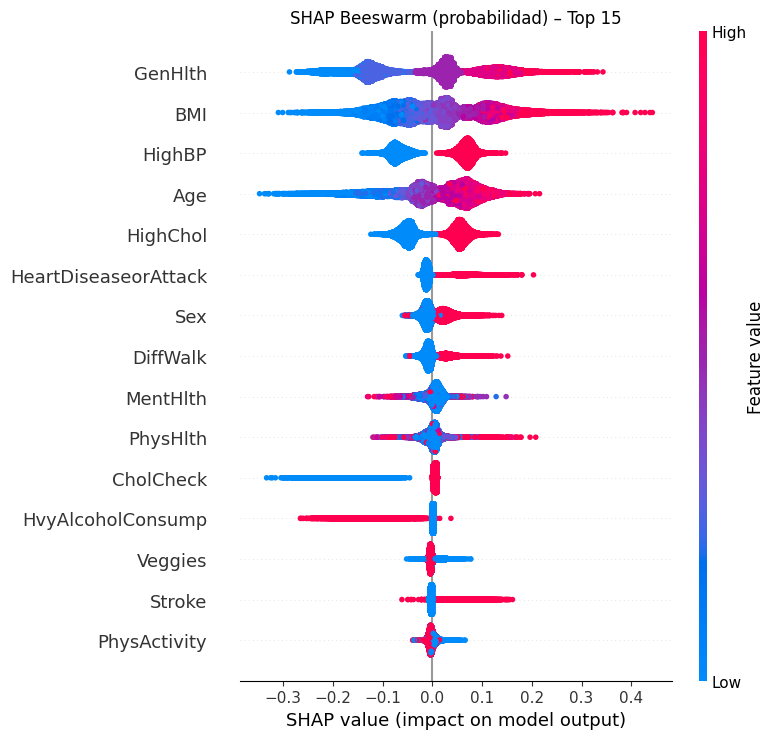

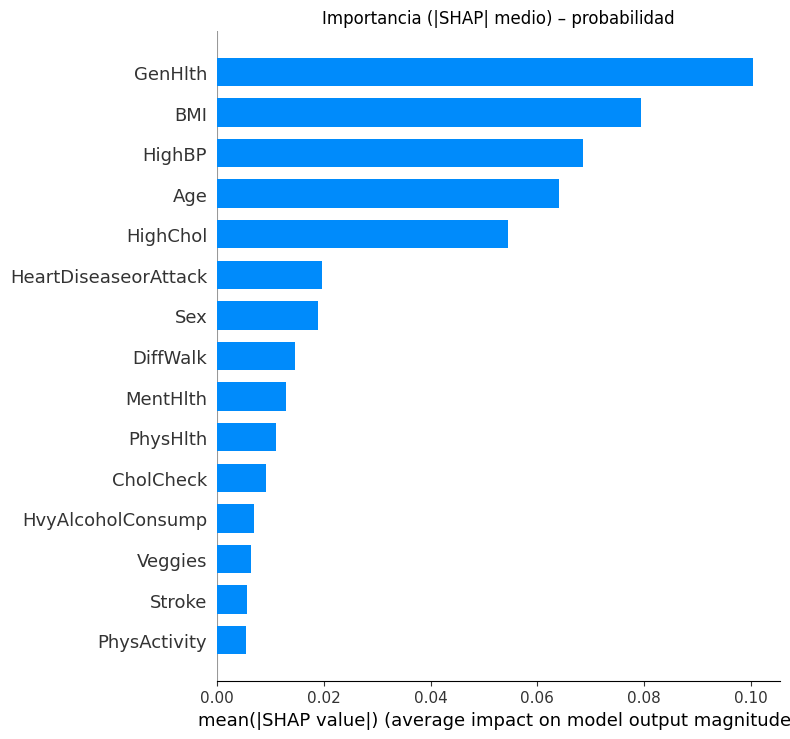

Base value (prob. media clase 1): 0.4714556816334715
Predicción (prob. clase 1) del paciente: 0.2461121380329132


/tmp/ipython-input-4255359129.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  proba_i = float(pipe.predict_proba(row_X)[:, 1])


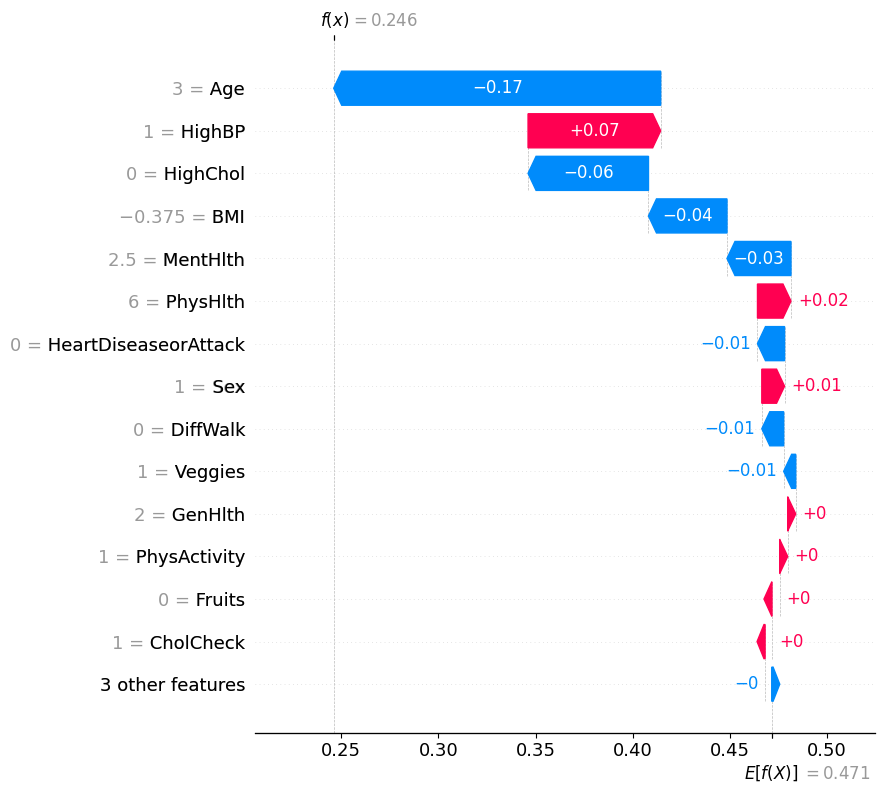

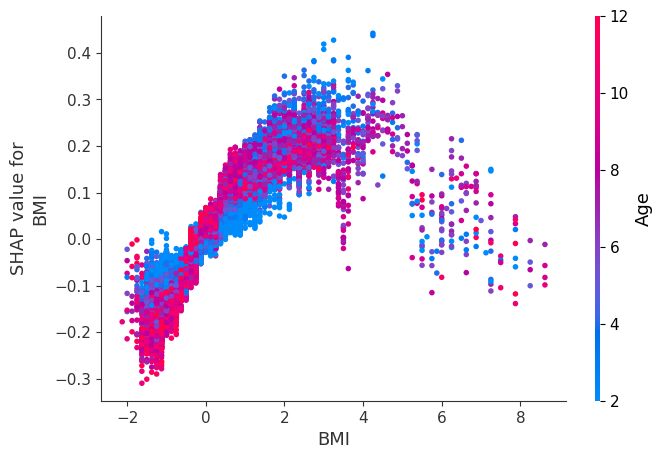

In [ ]:
# --- 0) Imports (asume que ya hiciste `!pip install shap`) ---
import shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt
shap.initjs()

target = "Diabetes"
y_all = df[target].astype(int)
X_all = df.drop(columns=[target])

Xt_all = pipe.named_steps["prep"].transform(X_all)   # DataFrame (por set_output='pandas')
xgb_model = pipe.named_steps["xgb"]

Xt_bg = Xt_all

explainer = shap.TreeExplainer(
    xgb_model,
    data=Xt_bg,
    model_output="probability",
    feature_perturbation="interventional"
)

# Submuestra solo para graficar y acelerar
N_VIS = None
if N_VIS is not None and N_VIS < len(Xt_all):
    rng = np.random.RandomState(42)
    vis_idx = rng.choice(Xt_all.index, size=N_VIS, replace=False)
    Xt_vis = Xt_all.loc[vis_idx]
else:
    Xt_vis = Xt_all

# Calcular SHAP (probabilidad)
sv = explainer(Xt_vis, check_additivity=False)  # sv: shap.Explanation

# Gráficos globales
try:
    shap.summary_plot(sv, Xt_vis, plot_type="dot", max_display=15, show=False)
except Exception:
    shap.summary_plot(sv.values, Xt_vis, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Beeswarm (probabilidad) – Top 15")
plt.tight_layout(); plt.show()

try:
    shap.summary_plot(sv, Xt_vis, plot_type="bar", max_display=15, show=False)
except Exception:
    shap.summary_plot(sv.values, Xt_vis, plot_type="bar", max_display=15, show=False)
plt.title("Importancia (|SHAP| medio) – probabilidad")
plt.tight_layout(); plt.show()

#Explicación LOCAL de un paciente concreto del dataset completo
i = Xt_all.index[0]
row_X  = X_all.loc[[i]]   # para predecir con el pipeline (features originales)
row_Xt = Xt_all.loc[[i]]  # para explicar (features transformadas)

sv_i = explainer(row_Xt, check_additivity=False)
print("Base value (prob. media clase 1):", float(np.atleast_1d(sv_i.base_values)[0]))

# Predicción del pipeline para ese paciente (en prob)
proba_i = float(pipe.predict_proba(row_X)[:, 1])
print("Predicción (prob. clase 1) del paciente:", proba_i)

# Waterfall
try:
    shap.plots.waterfall(sv_i[0], max_display=15)
except Exception:
    shap.waterfall_plot(
        shap.Explanation(values=sv_i.values[0],
                         base_values=np.atleast_1d(sv_i.base_values)[0],
                         data=row_Xt.values[0],
                         feature_names=row_Xt.columns.tolist()),
        max_display=15
    )

# Tomamos la feature con mayor |SHAP| medio
top_feature = Xt_vis.columns[np.argsort(np.abs(getattr(sv, "values", sv).mean(0)))[::-1][0]]
shap.dependence_plot(top_feature, getattr(sv, "values", sv), Xt_vis,
                     interaction_index='auto', show=True)


2. ¿Qué representa cada número en su resultado? (1 punto)

Los números en los gráficos son los valores SHAP, los cuales muestran el impacto de cada característica en la predicción de un modelo para un caso específico (por ejemplo, un paciente). Estos valores demuestran cuánto aporta cada característica (como la edad, BMI, presión arterial, etc.) al resultado final. Un valor SHAP positivo significa que esa característica está aumentando la probabilidad del resultado, en este caso sería alguna de las variables que se tiene en el dataset. En cambio, un valor SHAP negativo indica que esa característica está disminuyendo la probabilidad de ese resultado. En este caso, en el primer gráfico los puntos de color rojo representan valores altos de características, mientras que los azules indican valores bajos.

En el primer gráfico, los valores SHAP en el eje horizontal (por ejemplo, 0.10, 0.02) indican el impacto promedio de cada característica en la predicción del modelo. Características con valores más altos, como "GenHlth" (0.10), tienen mayor influencia, mientras que características con valores más bajos, como "PhysActivity" (0.02), tienen menos impacto.



3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

Si es posible atribuirle un significado a la a positividad y negatividad de los valores SHAP. Estos significan lo siguiente:

Si el valor SHAP es positivo, eso significa que la característica tiene un efecto que aumenta la probabilidad de que ocurra un evento. Por ejemplo, si una persona tiene un BMI más alto, su valor SHAP puede ser positivo, indicando que un mayor BMI aumenta la probabilidad de que el modelo prediga un evento negativo, como una enfermedad cardíaca.

Si el valor SHAP es negativo, significa que la característica reduce la probabilidad de un resultado positivo. Por ejemplo, un paciente que tiene buenos hábitos alimenticios, o buena salud en general, este podría tener un valor SHAP negativo en esa característica, lo que indicaría que esas buenas prácticas reducen la probabilidad de una enfermedad.

Estos valores son útiles porque permiten entender el cómo cada factor influye individualmente en la predicción, haciendo el modelo más interpretable a nivel de cada característica.

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

In [ ]:
# Inserte código para generar gráficos de aporte local aquí

Gráfico para la instancia 1


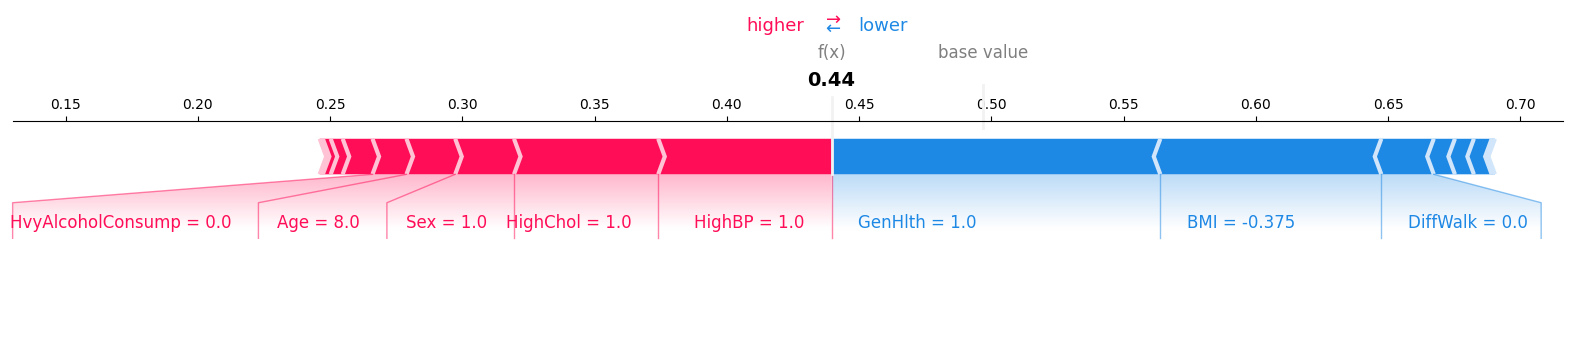

Gráfico para la instancia 9


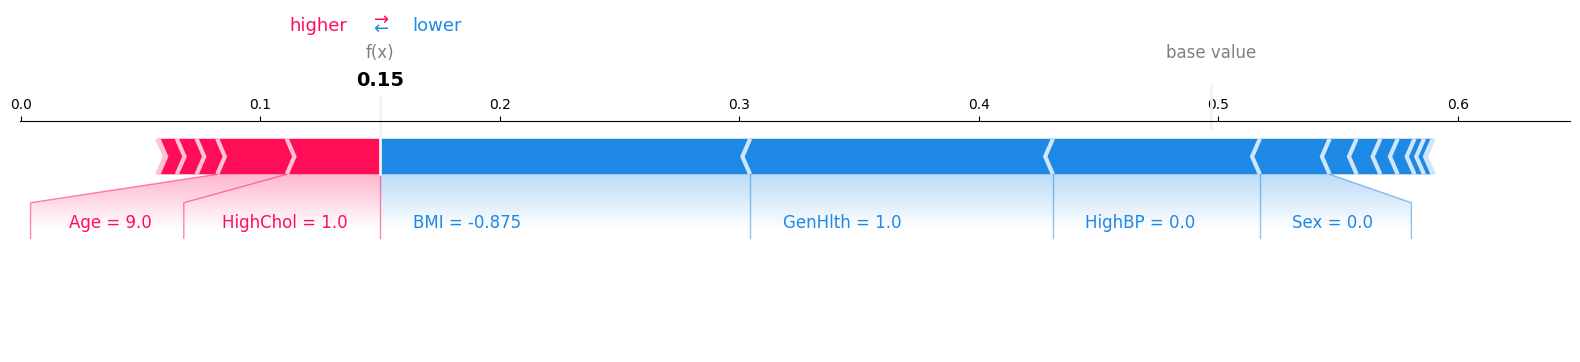

Gráfico para la instancia 150


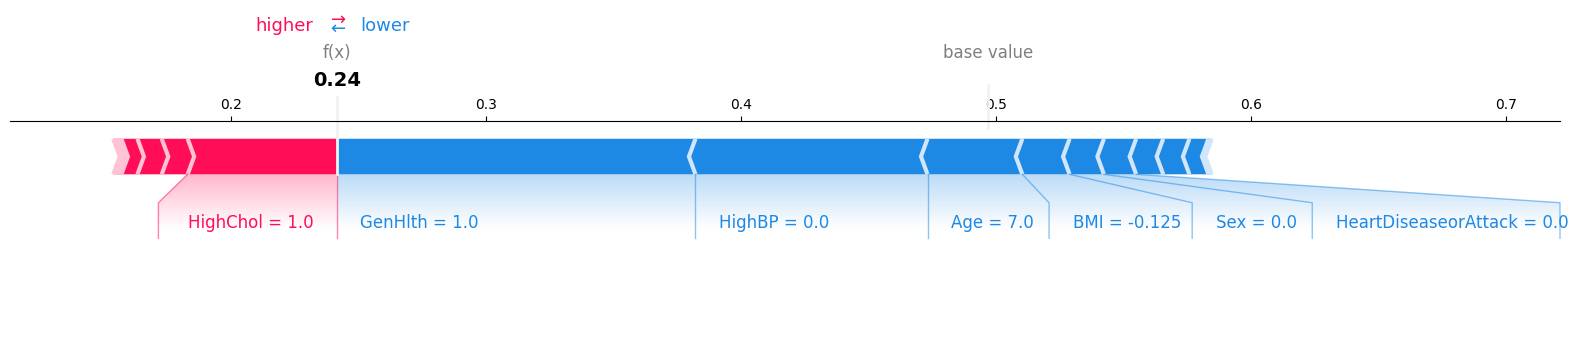

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt

_shap_prep = pipe.named_steps['prep']
_xgb_model = pipe.named_steps['xgb']

# Transformar los datos de prueba con el preprocesador
Xt_test = _shap_prep.transform(X_te)

# TreeExplainer para XGBoost en modo probabilidad
explainer = shap.TreeExplainer(
    _xgb_model,
    data=Xt_test,
    model_output="probability",
    feature_perturbation="interventional"
)

# Instancias que queremos visualizar son 1, 9 y 150
indices = [0, 8, 149]

# Visualización de los resultados para las instancias
shap.initjs()  # Inicia la visualización interactiva

for idx in indices:
    row_Xt = Xt_test[idx:idx+1]
    sv_instance = explainer(row_Xt, check_additivity=False)

    # Visualiza el aporte local para la instancia (
    print(f"Gráfico para la instancia {idx+1}")  # Para mostrar el índice 1-based

    # Force plot
    shap.force_plot(
        base_value=sv_instance.base_values[0],   # Valor base (promedio)
        shap_values=sv_instance.values[0],       # Los SHAP values de la instancia
        features=row_Xt,                         # Las características de la instancia
        feature_names=Xt_test.columns,           # Nombres de las características
        matplotlib=True,                         # Para que sea compatible con matplotlib
        show=True
    )


Interprete sus resultados y responda:

¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)


Las variables que afectan positivamente la probabilidad de tener diabetes son Edad, HighChol (colesterol alto) y GenHlth (salud general). HighBP (presión arterial alta) también tiene un impacto positivo en algunas instancias. En cuanto a las variables que afectan negativamente la probabilidad de diabetes, BMI (índice de masa corporal) y Sexo son las más influyentes en reducir la probabilidad de la enfermedad.



¿Existe algún patrón común entre las instancias analizadas? (1 punto)


Sí, existe un patrón común. Edad y HighChol tienen efectos positivos en todas las instancias analizadas, lo que indica que estos factores tienden a aumentar la probabilidad de diabetes. Por otro lado, BMI siempre tiene un efecto negativo, reduciendo la probabilidad de la enfermedad. GenHlth también muestra un efecto positivo consistente. Sexo y HighBP parecen tener un impacto más variable, dependiendo de la combinación con otras variables, lo que sugiere que sus efectos no son tan uniformes.




¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

Aunque los patrones observados en estas tres instancias sugieren que Edad, HighChol y GenHlth son variables con un impacto positivo, y BMI tiene un efecto negativo, no podemos generalizar estos resultados a todo el conjunto de datos con solo estas tres instancias. Para hacer una generalización que resulte más efectiva es necesario analizar un conjunto más grande de datos. Estas tres instancias representan una muy pequeña parte del conjunto de datos, por lo que las conclusiones podrían cambiar si se consideran más datos. Por lo tanto, sería recomendable realizar un análisis más completo para validar estos patrones en todo el dataset.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

In [ ]:
# Inserte código para generar gráficos de aporte global aquí

100%|===================| 70679/70692 [32:26<00:00]       

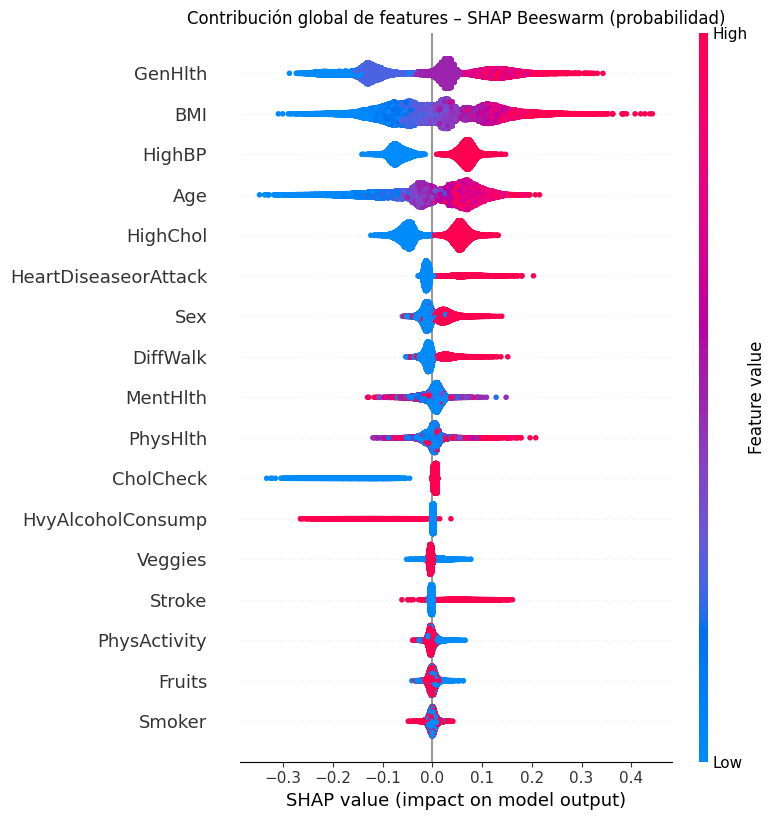

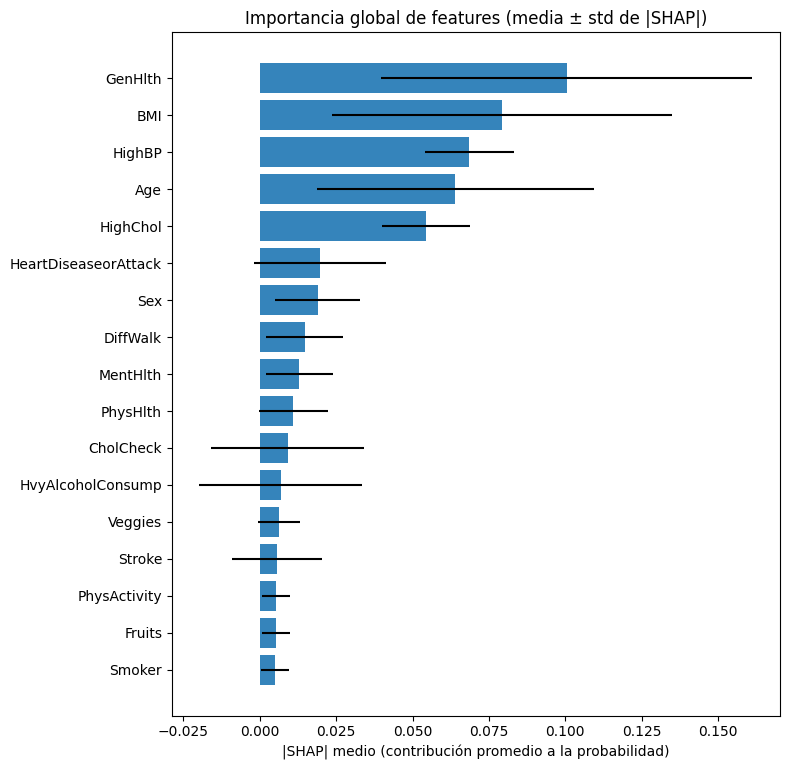

,feature,|SHAP|_mean,|SHAP|_std
0,GenHlth,0.100411,0.060820
1,BMI,0.079318,0.055673
2,HighBP,0.068609,0.014495
3,Age,0.064027,0.045301
4,HighChol,0.054497,0.014391
5,HeartDiseaseorAttack,0.019667,0.021573
6,Sex,0.018961,0.013949
7,DiffWalk,0.014697,0.012597
8,MentHlth,0.013010,0.010942
9,PhysHlth,0.011026,0.011413


In [12]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Aseguramos que los resultados sean reproducibles
shap.initjs()

# Preparar X e y a partir del dataset original
target = "Diabetes"
X_all = df.drop(columns=[target])

Xt_all = pipe.named_steps['prep'].transform(X_all)  # set_output('pandas')
xgb_model = pipe.named_steps['xgb']

# Calcular SHAP para todo el dataset
explainer = shap.TreeExplainer(
    xgb_model,
    data=Xt_all,
    model_output="probability",
    feature_perturbation="interventional")

# Calcular SHAP values para todo el conjunto de datos (X_all o Xt_all)
sv = explainer(Xt_all, check_additivity=False)  # shap.Explanation

# Gráfico contribuciones por feature
plt.figure(figsize=(8, 6))
shap.summary_plot(sv.values, Xt_all, plot_type="dot", max_display=20, show=False)
plt.title("Contribución global de features – SHAP Beeswarm (probabilidad)", fontsize=12)
plt.tight_layout()
plt.show()

# Gráfico de Barras con |SHAP| medio y desviación estándar
phi_abs = np.abs(sv.values)   # Tomamos el valor absoluto de las contribuciones
mean_abs = phi_abs.mean(axis=0)  # Media de |SHAP| por feature
std_abs  = phi_abs.std(axis=0, ddof=1)  # Desviación estándar de |SHAP|

# Ordenamos las features por la media de |SHAP|
order = np.argsort(mean_abs)[::-1]
feat = Xt_all.columns.to_numpy()[order]
m, s = mean_abs[order], std_abs[order]

TOP = min(20, len(feat))
plt.figure(figsize=(8, 0.4 * TOP + 1))
plt.barh(range(TOP), m[:TOP], xerr=s[:TOP], alpha=0.9)
plt.yticks(range(TOP), feat[:TOP])
plt.gca().invert_yaxis()
plt.xlabel("|SHAP| medio (contribución promedio a la probabilidad)")
plt.title("Importancia global de features (media ± std de |SHAP|)", fontsize=12)
plt.tight_layout()
plt.show()

# Tabla de las top-15 features para interpretación
topk = min(15, len(feat))
tabla_global = pd.DataFrame({
    "feature": feat[:topk],
    "|SHAP|_mean": m[:topk],
    "|SHAP|_std": s[:topk],
})
display(tabla_global)


En el aporte global de las características, según los valores de SHAP medios y su desviación estándar, se puede ver que las características como GenHlth, BMI, HighBP, Edad, y HighChol tienen un impacto considerable en la probabilidad de poseer diabetes. En específico, se puede notar que GenHlth tiene una alta contribución promedio, lo que sugiere que la salud general es una de las variables más influyentes. BMI es también una de las características más influyentes, lo que contradice un poco el análisis a nivel local, donde vimos que BMI puede reducir la probabilidad de diabetes en algunas instancias.

Este análisis global nos da una visión más generalizada de las variables que más contribuyen a la predicción, mientras que el análisis a nivel local se centra en instancias específicas, mostrando interacciones y efectos más elaborados al tener una mayor observación sobre lo que está pasando.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

In [ ]:
# Inserte código para generar gráficos de feature vs shap value aquí

In [14]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

binary_cols = ['Sex','HighChol','CholCheck','Smoker','HeartDiseaseorAttack','PhysActivity','Fruits','Veggies','HvyAlcoholConsump','DiffWalk','Stroke','HighBP']
cont_cols = ['BMI','MentHlth','PhysHlth']
ordinal_cols = ['Age','GenHlth']

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preproc_cont = Pipeline([('robust', RobustScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ('cont', preproc_cont, cont_cols),
        ('ord', ordinal_encoder, ordinal_cols),
        ('bin', 'passthrough', binary_cols),
    ],
    remainder='drop', verbose_feature_names_out=False
).set_output(transform='pandas')

target = 'Diabetes'
y = df[target].astype(int)
X = df.drop(columns=[target])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=1/3, random_state=42, stratify=y)

xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=42, n_jobs=-1
)

pipe = Pipeline([('prep', preprocessor), ('xgb', xgb)])

pipe.fit(X_tr, y_tr)

y_pred = pipe.predict(X_te)
print(classification_report(y_te, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.774     0.703     0.737     11782
           1      0.728     0.795     0.760     11782

    accuracy                          0.749     23564
   macro avg      0.751     0.749     0.749     23564
weighted avg      0.751     0.749     0.749     23564



100%|===================| 70679/70692 [32:46<00:00]       

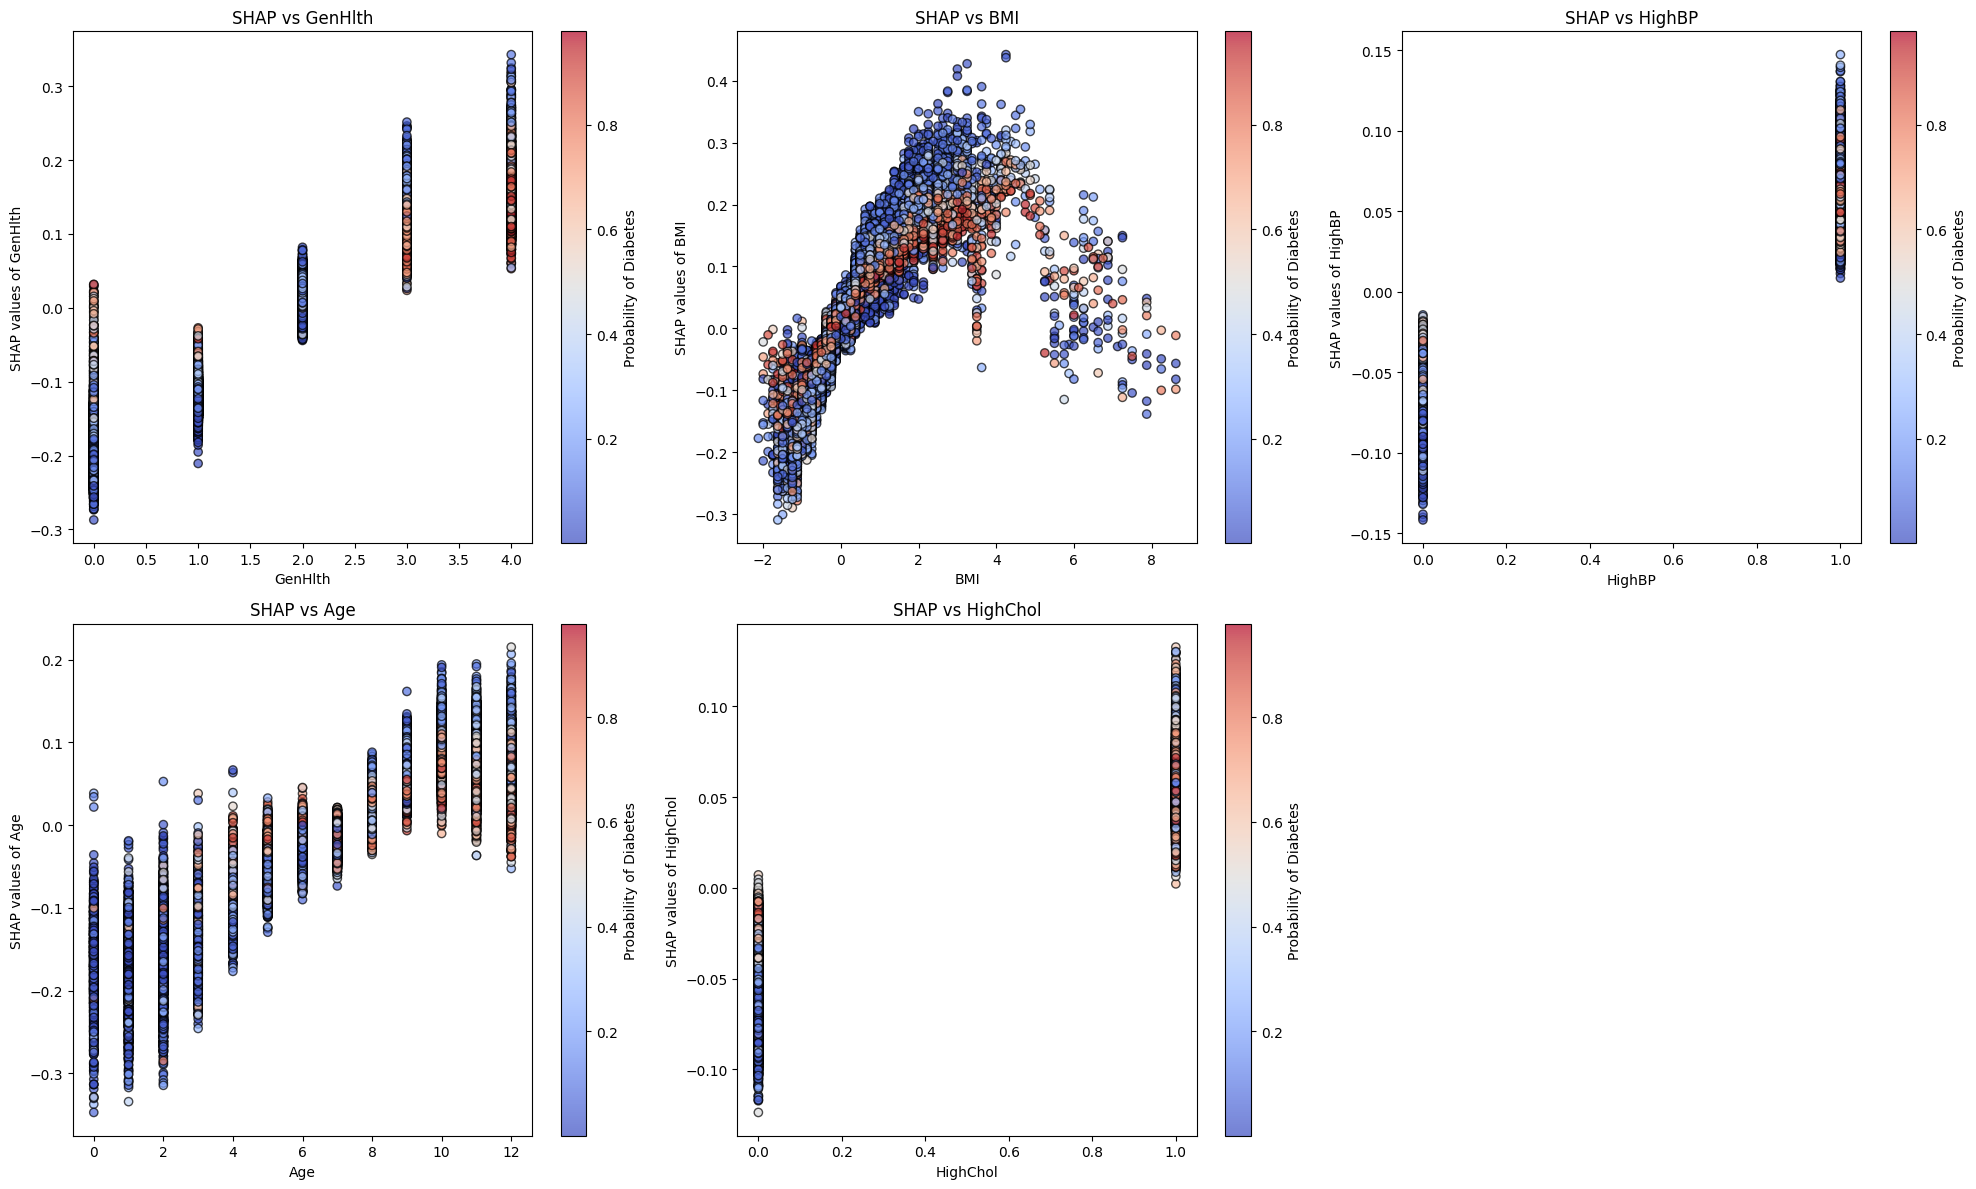

In [15]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Inicializamos SHAP
shap.initjs()

target = "Diabetes"
X_all = df.drop(columns=[target])

Xt_all = pipe.named_steps['prep'].transform(X_all)
xgb_model = pipe.named_steps['xgb']

#Calcular SHAP para todo el dataset
explainer = shap.TreeExplainer(
    xgb_model,
    data=Xt_all,  # Usamos todo el conjunto de datos
    model_output="probability",  # Probabilidad de clase 1 (diabetes)
    feature_perturbation="interventional")

# Calcular SHAP values para todo el conjunto de datos (X_all o Xt_all)
sv = explainer(Xt_all, check_additivity=False)
# Calcular la importancia global (media de |SHAP|) y seleccionar las 5 features más importantes
phi_abs = np.abs(sv.values)  # Tomamos el valor absoluto de las contribuciones
mean_abs = phi_abs.mean(axis=0)  # Media de |SHAP| por feature

# Ordenamos las features por la media de |SHAP|
order = np.argsort(mean_abs)[::-1]
feat = Xt_all.columns.to_numpy()[order]

# Seleccionamos las 5 features más importantes
top_5_features = feat[:5]

# Generar los scatterplots entre los SHAP values y las 5 features más importantes
plt.figure(figsize=(20, 12))

# Para cada feature más importante, generamos un scatterplot
for i, feature in enumerate(top_5_features):
    plt.subplot(2, 3, i+1)

    # Obtener los SHAP values y los valores de la feature
    shap_values = sv.values[:, order[i]]
    feature_values = Xt_all[feature]

    # Probabilidades de tener diabetes (predicciones)
    proba = pipe.predict_proba(Xt_all)[:, 1]

    # Crear el scatterplot
    plt.scatter(feature_values, shap_values, c=proba, cmap='coolwarm', alpha=0.7, edgecolors="k")
    plt.xlabel(feature)
    plt.ylabel(f'SHAP values of {feature}')
    plt.title(f'SHAP vs {feature}')
    plt.colorbar(label="Probability of Diabetes")

plt.tight_layout()
plt.show()


Se visualiza que:

A medida que la salud general mejora (de 0 a 4), los valores de SHAP son positivos, lo que sugiere que una mejor salud general disminuye la probabilidad de tener diabetes.

La relación entre BMI y los valores de SHAP es no lineal. A medida que el BMI aumenta, la probabilidad de diabetes también lo hace, pero en BMI muy altos, la probabilidad parece estabilizarse.

Las personas con hipertensión (valor 1) tienen valores de SHAP positivos, lo que indica una mayor probabilidad de diabetes, mientras que aquellas sin hipertensión (valor 0) muestran valores de SHAP más bajos.

A medida que aumenta la edad, los valores de SHAP también aumentan, lo que indica que el riesgo de diabetes se incrementa con la edad.

Similar a la hipertensión, las personas con colesterol alto tienen valores de SHAP positivos, lo que sugiere una mayor probabilidad de diabetes, mientras que aquellos sin colesterol alto tienen valores más bajos de SHAP.

n resumen, las características como el BMI, la edad, el colesterol alto y la hipertensión están asociadas con un mayor riesgo de diabetes, mientras que una mejor salud general reduce esa probabilidad.


### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

In [ ]:
# Inserte código para generar gráficos PDP aquí

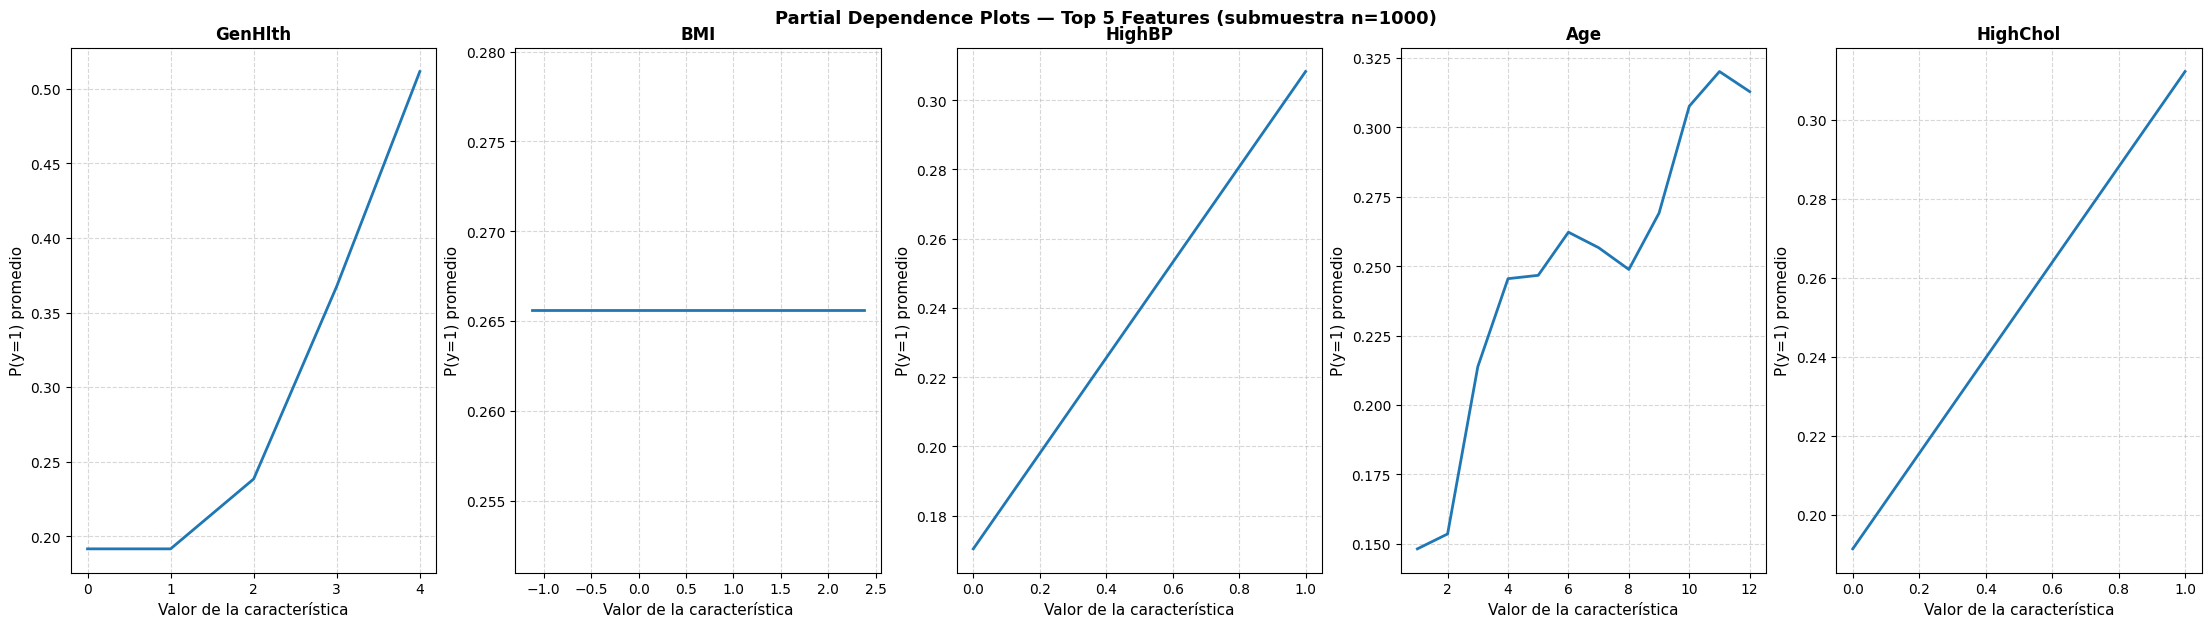

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Media de |SHAP| para todas las características
mean_abs_shap = np.abs(sv.values).mean(axis=0)

# Submuestra de 1000 observaciones
n = 1000
idx = np.random.choice(len(Xt_all), size=n, replace=False)
X_sub = Xt_all.iloc[idx].copy()

# Función para calcular PDP de una feature específica
def pdp_for_feature(pipe, X_base, col, n_grid=30):
    x = X_base[col]

    # Si la característica tiene menos de 2 valores únicos, se crea el grid con esos valores
    if x.nunique() <= 2:
        grid = np.sort(x.unique())
    else:
        # Generar los valores de la característica para el grid
        grid = np.quantile(x, np.linspace(0.02, 0.98, n_grid))
        grid = np.unique(np.round(grid, 6))

    y_mean = []
    for v in grid:
        X_tmp = X_base.copy()
        X_tmp[col] = v  # Reemplazamos los valores de la columna por el valor del grid
        p = pipe.predict_proba(X_tmp)[:, 1]  # Obtenemos las probabilidades de la clase positiva
        y_mean.append(p.mean())  # Promedio de la probabilidad para ese valor de la característica

    return grid, np.array(y_mean)

# Graficar los PDP para las 5 características con mayor impacto
fig, axes = plt.subplots(1, 5, figsize=(22, 6), constrained_layout=True)
top_5_features = Xt_all.columns[np.argsort(mean_abs_shap)[-5:]][::-1]  # Top 5 características más importantes

# gráficos
for ax, f in zip(axes, top_5_features):
    xs, ys = pdp_for_feature(pipe, X_sub, f, n_grid=30)  # Calculamos el PDP
    ax.plot(xs, ys, lw=2, color='tab:blue')
    ax.set_title(f'{f}', fontsize=12, fontweight='bold')
    ax.set_xlabel("Valor de la característica", fontsize=11)
    ax.set_ylabel("P(y=1) promedio", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.suptitle("Partial Dependence Plots — Top 5 Features (submuestra n=1000)", y=1.02, fontsize=13, fontweight='bold')

plt.show()


Se puede notar que el valor de la características en relación con la probalid


En los gráficos de "Partial Dependence Plots" se muestra cómo cada característica influye en la probabilidad de que el modelo prediga (y = 1).

Para GenHlth que es el estado general de salud, se ve que a medida que mejora la salud, la probabilidad aumenta. Es decir, las personas con un mejor estado de salud general no parecen tener una probabilidad mucho mayor de tener diabetes. Esto depende del valor que se le asigne a la variable y su interpretación del estado general de la salud. Si que tenga un valor más bajo este más relacionado a una probabilidad más baja, puede signfocar que tiene un mejor estado de salud en escala.

En el caso de BMI que es el índice de masa corporal, no se observa una relación clara, lo que indica que esta variable no afecta mucho el resultado en el rango mostrado. En este caso, identificamos que es un caso raro y se debe asociar a problemas con la muestra de los datos que está tomando. Sin embargo, creemos que esta debería tener un comportamiento similar a los otros gráficos (lineal y creciente), por lo visto en el ítem anterior.

Para HighBP que es la presión arterial alta, la probabilidad aumenta cuando la persona tiene hipertensión, lo que sugiere que tener presión alta está asociado con un mayor riesgo de que el modelo prediga.

En Age es la Edad, la probabilidad también aumenta con la edad, aunque de manera no lineal, indicando que las personas mayores tienen más probabilidad de experimentar tener la enfermedad.

Finalmente, para HighChol que es el Colesterol alto, la relación es similar a la de HighBP, es decir que tener colesterol alto aumenta la probabilidad de ( y = 1 ).

En general, algunas variables como el estado de salud, la hipertensión y el colesterol alto están claramente asociadas con la probabilidad de salida, mientras que otras, como el BMI, no parecen influir tanto. Sin embargo, estas conclusiones deben verificarse en todo el conjunto de datos para confirmarlas.


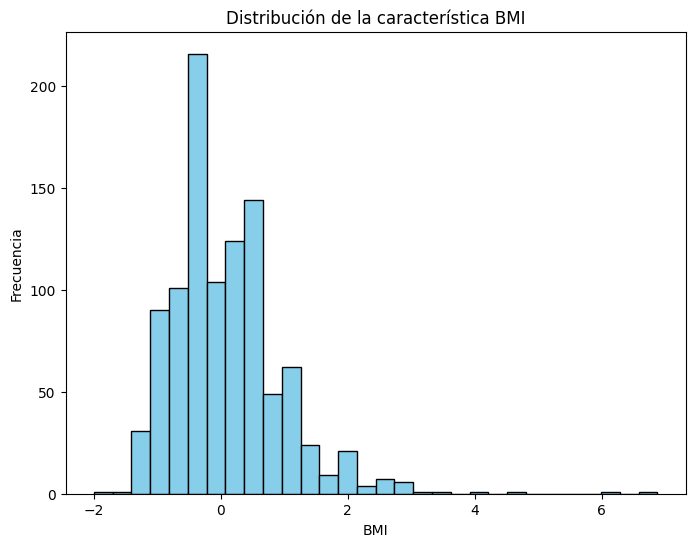

In [43]:
# Ver la distribución de 'BMI'
plt.figure(figsize=(8, 6))
plt.hist(X_sub['BMI'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la característica BMI')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()


## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [25]:
!pip install alibi

In [11]:
from alibi.explainers import AnchorTabular

In [50]:
import numpy as np
import pandas as pd
from alibi.explainers import AnchorTabular

# Preparar datos preprocesados para el conjunto completo
target = 'Diabetes'
y_all = df[target].astype(int)
X_all = df.drop(columns=[target])

# Transformar todo el conjunto de datos
Xt_all = pipe.named_steps['prep'].transform(X_all)
xgb_model = pipe.named_steps['xgb']

# Convertir a numpy arrays para AnchorTabular
X_train_np = pipe.named_steps['prep'].transform(X_tr).values
X_all_np = Xt_all.values
feature_names = list(Xt_all.columns)

# Crear el explainer AnchorTabular
explainer = AnchorTabular(
    predictor=xgb_model.predict,
    feature_names=feature_names,
    categorical_names={},  # No hay variables categóricas después del preprocesamiento
    seed=42
)

# Ajustar el explainer con datos de entrenamiento
explainer.fit(X_train_np, disc_perc=[25, 50, 75])

print("Explainer AnchorTabular configurado correctamente")

# Función para explicar una instancia específica
def explain_instance(idx):
    print(f"\n=== EXPLICACION PARA LA OBSERVACION {idx} ===")

    # Obtener la instancia
    instance = X_all_np[idx]

    # Obtener la predicción original
    pred = xgb_model.predict([instance])[0]
    pred_proba = xgb_model.predict_proba([instance])[0]

    print(f"Prediccion: {pred} (Clase {'Diabetes' if pred == 1 else 'No Diabetes'})")
    print(f"Probabilidades: No Diabetes={pred_proba[0]:.3f}, Diabetes={pred_proba[1]:.3f}")

    # Generar explicación con anchor
    explanation = explainer.explain(instance, threshold=0.95)

    print(f"\nReglas encontradas:")
    print(f"Anchor: {explanation.anchor}")
    print(f"Precision: {explanation.precision:.3f}")
    print(f"Coverage: {explanation.coverage:.3f}")

    # Mostrar las reglas de forma más legible
    print(f"\nReglas interpretables:")
    for i, rule in enumerate(explanation.anchor):
        print(f"  {i+1}. {rule}")

    return explanation

explanations = {}

# Definir los índices a explicar
idx = 1000
idx2 = 3001
idx3 = 5751

# Observación idx
explanations[idx] = explain_instance(idx)

# Observación idx2
explanations[idx2] = explain_instance(idx2)

# Observación idx3
explanations[idx3] = explain_instance(idx3)

# Análisis general de las reglas
print("\n" + "="*60)
print("ANALISIS GENERAL DE LAS REGLAS")
print("="*60)

total_instances = len(X_all_np)
print(f"Total de instancias en el dataset: {total_instances}")

for idx, exp in explanations.items():
    coverage_count = int(exp.coverage * total_instances)
    print(f"\nObservacion {idx}:")
    print(f"  - Precision de las reglas: {exp.precision:.3f}")
    print(f"  - Coverage: {exp.coverage:.3f} ({coverage_count} instancias)")
    print(f"  - Numero de reglas: {len(exp.anchor)}")

# Evaluar qué tan bien funcionan las reglas en todo el dataset
print(f"\n=== EVALUACION DE REGLAS EN TODO EL DATASET ===")

def evaluate_rules_on_dataset(explanation, X_data, feature_names):
    """
    Evalúa las reglas anchor en todo el dataset
    """
    rules_satisfied = np.ones(len(X_data), dtype=bool)

    print(f"Evaluando reglas: {explanation.anchor}")

    # Parsear y aplicar cada regla
    for rule in explanation.anchor:
        # Extraer información de la regla (simplificado para las reglas numéricas)
        if '<=' in rule:
            parts = rule.split(' <= ')
            feature_name = parts[0].strip()
            threshold = float(parts[1])

            # Encontrar el índice de la feature
            if feature_name in feature_names:
                feature_idx = feature_names.index(feature_name)
                rule_mask = X_data[:, feature_idx] <= threshold
                rules_satisfied &= rule_mask

                print(f"  - Regla '{rule}': {rule_mask.sum()} instancias cumplen")

        elif '>=' in rule:
            parts = rule.split(' >= ')
            feature_name = parts[0].strip()
            threshold = float(parts[1])

            if feature_name in feature_names:
                feature_idx = feature_names.index(feature_name)
                rule_mask = X_data[:, feature_idx] >= threshold
                rules_satisfied &= rule_mask

                print(f"  - Regla '{rule}': {rule_mask.sum()} instancias cumplen")

    total_satisfied = rules_satisfied.sum()
    coverage_actual = total_satisfied / len(X_data)

    print(f"  - Total instancias que cumplen TODAS las reglas: {total_satisfied}")
    print(f"  - Coverage real calculado: {coverage_actual:.3f}")
    print(f"  - Coverage reportado por Anchor: {explanation.coverage:.3f}")

    return rules_satisfied

# Ejecutar la evaluación para cada explicación
for idx, exp in explanations.items():
    print(f"\n--- Evaluando reglas para observación {idx} ---")
    rules_mask = evaluate_rules_on_dataset(exp, X_all_np, feature_names)

    # Calcular precisión en las instancias que cumplen las reglas
    if rules_mask.sum() > 0:
        predictions_on_rules = xgb_model.predict(X_all_np[rules_mask])
        accuracy_on_rules = (predictions_on_rules == 0).mean()  # Todas deberían ser clase 0
        print(f"  - Precisión real en instancias que cumplen reglas: {accuracy_on_rules:.3f}")
    else:
        print("  - No hay instancias que cumplan todas las reglas")

# Análisis conjunto de todas las reglas
print(f"\n=== ANALISIS CONJUNTO ===")
all_rules_union = np.zeros(len(X_all_np), dtype=bool)

for idx, exp in explanations.items():
    rules_mask = evaluate_rules_on_dataset(exp, X_all_np, feature_names)
    all_rules_union |= rules_mask

total_covered = all_rules_union.sum()
union_coverage = total_covered / len(X_all_np)

print(f"Población total cubierta por al menos una regla: {total_covered} ({union_coverage:.3f})")
print(f"Esto representa el {union_coverage*100:.1f}% del dataset completo")

Explainer AnchorTabular configurado correctamente

=== EXPLICACION PARA LA OBSERVACION 1000 ===
Prediccion: 0 (Clase No Diabetes)
Probabilidades: No Diabetes=0.637, Diabetes=0.363

Reglas encontradas:
Anchor: ['GenHlth <= 1.00', 'HighBP <= 0.00', 'BMI <= -0.50']
Precision: 0.991
Coverage: 0.112

Reglas interpretables:
  1. GenHlth <= 1.00
  2. HighBP <= 0.00
  3. BMI <= -0.50

=== EXPLICACION PARA LA OBSERVACION 3001 ===
Prediccion: 0 (Clase No Diabetes)
Probabilidades: No Diabetes=0.940, Diabetes=0.060

Reglas encontradas:
Anchor: ['BMI <= -0.50', 'HighBP <= 0.00', 'HighChol <= 0.00']
Precision: 0.974
Coverage: 0.121

Reglas interpretables:
  1. BMI <= -0.50
  2. HighBP <= 0.00
  3. HighChol <= 0.00

=== EXPLICACION PARA LA OBSERVACION 5751 ===
Prediccion: 0 (Clase No Diabetes)
Probabilidades: No Diabetes=0.882, Diabetes=0.118

Reglas encontradas:
Anchor: ['BMI <= -0.50', 'GenHlth <= 1.00']
Precision: 0.950
Coverage: 0.148

Reglas interpretables:
  1. BMI <= -0.50
  2. GenHlth <= 1.00

Las reglas propuestas para las observaciones 1000, 3001 y 5751 tienen sentido, ya que se basan en características relevantes de salud que están directamente relacionadas con la diabetes, como el estado general de salud (GenHlth), la presión arterial (HighBP), el índice de masa corporal (BMI) y el colesterol alto (HighChol). Estas variables influyen en la probabilidad de tener diabetes, lo que hace que las reglas sean coherentes con lo que esperaríamos al analizar el comportamiento del modelo.

Sin embargo, aunque las reglas son precisas en sus respectivas instancias (con precisiones superiores al 95%), su cobertura es limitada. En total, las reglas propuestas solo cubren el 18.6% de la población del conjunto de datos. Esto significa que las reglas solo explican una pequeña fracción de las predicciones realizadas por el modelo, lo que reduce su utilidad para comprender completamente cómo el modelo toma decisiones en el conjunto de datos total.

La precisión indica cuán bien estas reglas predicen la clase correcta, por ejemplo, en la observación 1000, la precisión es 0.991, lo que significa que el 99.1% de las instancias que cumplen las reglas son correctas. El coverage muestra el porcentaje de instancias que cumplen con las reglas, como en la observación 1000, donde cubren el 11.2% del dataset.

En el análisis general, las reglas cubren un porcentaje del dataset, como el 11.2% en la observación 1000. La precisión real de las instancias que cumplen las reglas es alta (por ejemplo, 0.997 en la observación 1000). En total, las reglas cubren el 18.6% del dataset.



-


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

A lo largo de este laboratorio se han visualizado distintas técnicas de interpretabilidad aplicadas a un modelo de clasificación de diabetes. En donde se pudo identificar que cada una tiene perspectivas únicas dependiendo del tipo de funcionamiento del algoritmo. Con esto se permite evaluar cuáles métodos resultan más efectivos según el contexto.

En términos de robustez y confiabilidad, el método de permutación de importancias demostró ser superior a las medidas de XGBoost. Mientras que las importancias como weight, cover y gain pueden verse influenciadas por la estructura interna del algoritmo, esto se da ya que la permutación evalúa directamente el impacto en la métrica de desempeño.

Además, se idenficó que existe una consistencia en las 30 repeticiones, lo que se refleja en bajas desviaciones estándar, lo que  permite confirmar a las variables identificadas como más relevantes, las cuales son salud general, BMI, edad, presión arterial y colesterol alto.

Los valores SHAP dan un análisis global como local, con lo que se logra tener una visión más completa. Lo anterior es muy relevante, ya que es útil en contextos médicas, donde es necesario comprender tanto los patrones generales como el comportamiento de cada paciente, ya que pueden haber casos en que hay particularidades propias de cada uno.

Por otro lado, se puede identificar también la dirección de su efecto, añade una mayor calidad de interpretación a este tipo de análisis.

Los gráficos de dependencia parcial revelaron relaciones funcionales entre variables y probabilidad de diabetes que no son evidentes en otros análisis. Estas visualizaciones permitieron identificar umbrales críticos y comportamientos no lineales, información valiosa para comprender cómo el modelo toma sus decisiones en diferentes rangos de valores.

Respecto a la aplicabilidad en el contexto clínico planteado, los métodos agnósticos locales resultan más apropiados para el problema del Dr. Simi. En este tipo de datasets relacionados a problemas médicos se requiere explicaciones personalizadas que permitan a cada paciente comprender los factores que influyen en su diagnóstico particular. En este sentido, las explicaciones SHAP individuales y el sistema de reglas AnchorTabular dan resultados más efectivos que los análisis globales.

Sin embargo, esto no implica que los métodos globales no sean útiles, hay que tener en consideración que estos dan una comprensión general del comportamiento del modelo, lo cual es clave para mantener analizar el comportamiento y detectar posibles sesgos. La combinación de ambos enfoques da una interpretación más completa.

En conclusión, la interpretabilidad efectiva en este tipo de problema necesita de un enfoque que combine métodos globales para el entendimiento técnico del modelo con métodos locales.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>